In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

print(" Libraries loaded successfully")

 Libraries loaded successfully


In [2]:
PATH = 'data/'

orders    = pd.read_csv(PATH + 'olist_orders_dataset.csv')
items     = pd.read_csv(PATH + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(PATH + 'olist_order_payments_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')
products  = pd.read_csv(PATH + 'olist_products_dataset.csv')
sellers   = pd.read_csv(PATH + 'olist_sellers_dataset.csv')
reviews   = pd.read_csv(PATH + 'olist_order_reviews_dataset.csv')
category  = pd.read_csv(PATH + 'product_category_name_translation.csv')

# Kiểm tra shape từng bảng
for name, d in [('orders',orders), ('items',items), ('payments',payments),
                ('customers',customers), ('products',products),
                ('sellers',sellers), ('reviews',reviews)]:
    print(f"  {name:<12}: {d.shape[0]:>7,} rows  |  {d.shape[1]} cols")


  orders      :  99,441 rows  |  8 cols
  items       : 112,650 rows  |  7 cols
  payments    : 103,886 rows  |  5 cols
  customers   :  99,441 rows  |  5 cols
  products    :  32,951 rows  |  9 cols
  sellers     :   3,095 rows  |  4 cols
  reviews     :  99,224 rows  |  7 cols


In [3]:
print("━"*55)
print("  ORDERS TABLE — Cột & kiểu dữ liệu")
print("━"*55)
print(orders.dtypes)

print("\n━"*2 + "━"*53)
print("  5 dòng đầu của bảng ORDERS")
print("━"*55)
orders.head()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ORDERS TABLE — Cột & kiểu dữ liệu
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

━
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  5 dòng đầu của bảng ORDERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
print("MISSING VALUES SUMMARY")
print("━"*50)

for name, d in [('orders',orders), ('items',items),
                ('payments',payments), ('customers',customers),
                ('products',products), ('reviews',reviews)]:
    missing = d.isnull().sum().sum()
    pct     = missing / (d.shape[0] * d.shape[1]) * 100
    bar     = '█' * int(pct) + '░' * (10 - int(pct))
    print(f"  {name:<12}: [{bar}] {pct:5.2f}%  ({missing} cells)")

MISSING VALUES SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  orders      : [░░░░░░░░░░]  0.62%  (4908 cells)
  items       : [░░░░░░░░░░]  0.00%  (0 cells)
  payments    : [░░░░░░░░░░]  0.00%  (0 cells)
  customers   : [░░░░░░░░░░]  0.00%  (0 cells)
  products    : [░░░░░░░░░░]  0.83%  (2448 cells)
  reviews     : [█████████████████████] 21.01%  (145903 cells)


In [5]:
print("━"*55)
print("  ORDERS TABLE — Cột & kiểu dữ liệu")
print("━"*55)
print(orders.dtypes)
print(f"\n5 dòng đầu:")
orders.head()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ORDERS TABLE — Cột & kiểu dữ liệu
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

5 dòng đầu:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
print("MISSING VALUES SUMMARY")
print("━"*50)

for name, d in [('orders',orders), ('items',items),
                ('payments',payments), ('customers',customers),
                ('products',products), ('reviews',reviews)]:
    missing = d.isnull().sum().sum()
    pct     = missing / (d.shape[0] * d.shape[1]) * 100
    bar     = '█' * int(pct) + '░' * (10 - int(pct))
    print(f"  {name:<12}: [{bar}] {pct:5.2f}%  ({missing} cells)")

MISSING VALUES SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  orders      : [░░░░░░░░░░]  0.62%  (4908 cells)
  items       : [░░░░░░░░░░]  0.00%  (0 cells)
  payments    : [░░░░░░░░░░]  0.00%  (0 cells)
  customers   : [░░░░░░░░░░]  0.00%  (0 cells)
  products    : [░░░░░░░░░░]  0.83%  (2448 cells)
  reviews     : [█████████████████████] 21.01%  (145903 cells)


In [7]:
# Chuyển cột datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Merge tất cả bảng lại
df = orders.merge(items,     on='order_id',   how='left') \
           .merge(payments,  on='order_id',   how='left') \
           .merge(customers, on='customer_id', how='left') \
           .merge(products,  on='product_id',  how='left') \
           .merge(category,  on='product_category_name', how='left') \
           .merge(reviews[['order_id','review_score']],
                  on='order_id', how='left')

print(f"✅ Merged shape : {df.shape}")
print(f"   Columns      : {df.columns.tolist()}")

✅ Merged shape : (119143, 32)
   Columns      : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'review_score']


In [8]:
# Chỉ lấy đơn hàng đã giao thành công
df_clean = df[df['order_status'] == 'delivered'].copy()

# Tạo các cột thời gian
df_clean['year']         = df_clean['order_purchase_timestamp'].dt.year
df_clean['month']        = df_clean['order_purchase_timestamp'].dt.month
df_clean['year_month']   = df_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_clean['weekday']      = df_clean['order_purchase_timestamp'].dt.day_name()

# Tính số ngày giao hàng thực tế
df_clean['delivery_days'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_purchase_timestamp']
).dt.days

# Loại bỏ dữ liệu bất thường
df_clean = df_clean[
    (df_clean['delivery_days'] > 0) &
    (df_clean['payment_value'] > 0)
]

print(f"✅ Clean dataset : {df_clean.shape}")
print(f"   Thời gian     : "
      f"{df_clean['order_purchase_timestamp'].min().date()} → "
      f"{df_clean['order_purchase_timestamp'].max().date()}")
print(f"   Tổng doanh thu: {df_clean['payment_value'].sum():,.0f} BRL")




✅ Clean dataset : (115689, 37)
   Thời gian     : 2016-10-03 → 2018-08-29
   Tổng doanh thu: 19,874,548 BRL


### Doanh thu theo tháng


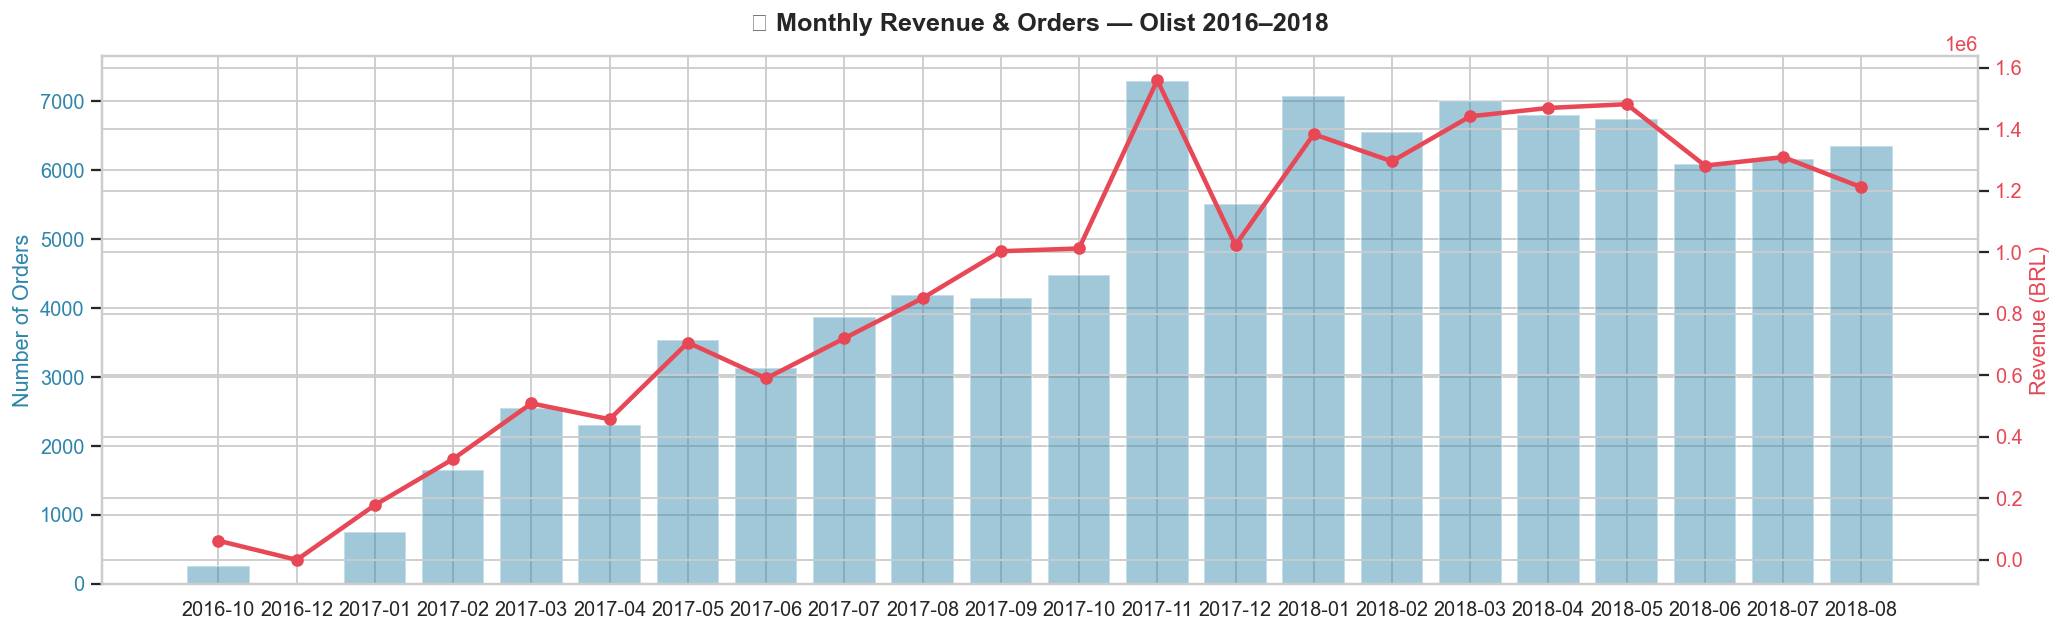

✅ Chart 1 saved!


In [9]:
monthly = df_clean.groupby('year_month').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 5))

# Cột xanh = số đơn hàng
ax1.bar(monthly['year_month'], monthly['orders'],
        color='#2E86AB', alpha=0.45, label='Orders')
ax1.set_ylabel('Number of Orders', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')

# Đường đỏ = doanh thu
ax2 = ax1.twinx()
ax2.plot(monthly['year_month'], monthly['revenue'],
         color='#E84855', marker='o', linewidth=2.5,
         markersize=6, label='Revenue')
ax2.set_ylabel('Revenue (BRL)', color='#E84855')
ax2.tick_params(axis='y', labelcolor='#E84855')

plt.title('📈 Monthly Revenue & Orders — Olist 2016–2018',
          fontsize=14, fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
fig.tight_layout()
plt.savefig('chart_01_monthly.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

### Doanh thu theo Bang


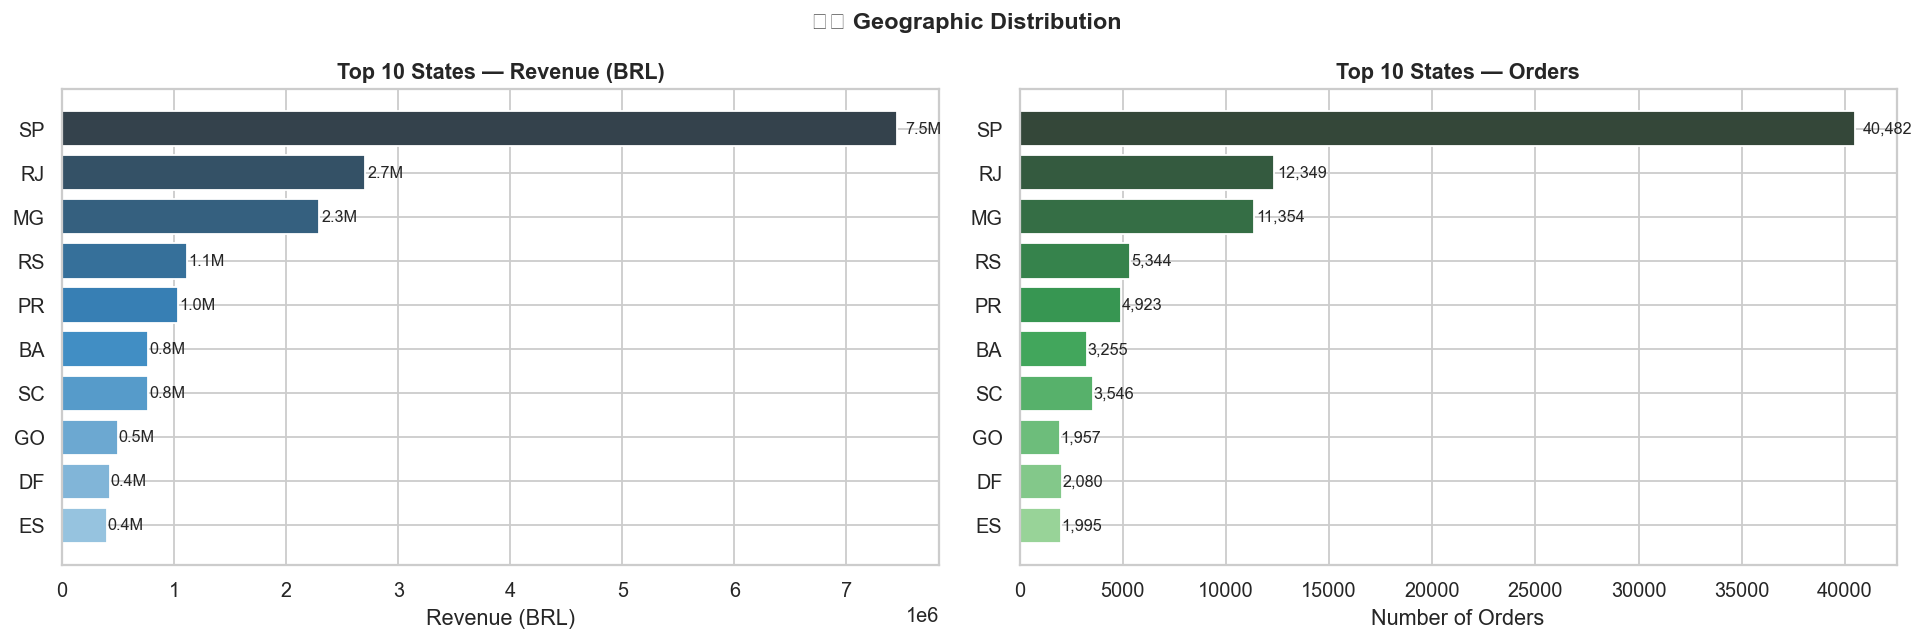

✅ Chart 2 saved!


In [10]:
state = df_clean.groupby('customer_state').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart trái — Revenue
bars1 = axes[0].barh(state['customer_state'][::-1],
                     state['revenue'][::-1],
                     color=sns.color_palette('Blues_d', 10))
axes[0].set_title('Top 10 States — Revenue (BRL)', fontweight='bold')
axes[0].set_xlabel('Revenue (BRL)')
for bar, val in zip(bars1, state['revenue'][::-1]):
    axes[0].text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{val/1e6:.1f}M', va='center', fontsize=9)

# Chart phải — Orders
bars2 = axes[1].barh(state['customer_state'][::-1],
                     state['orders'][::-1],
                     color=sns.color_palette('Greens_d', 10))
axes[1].set_title('Top 10 States — Orders', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
for bar, val in zip(bars2, state['orders'][::-1]):
    axes[1].text(val * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)

plt.suptitle('🗺️ Geographic Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_02_states.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

### Danh mục theo tháng

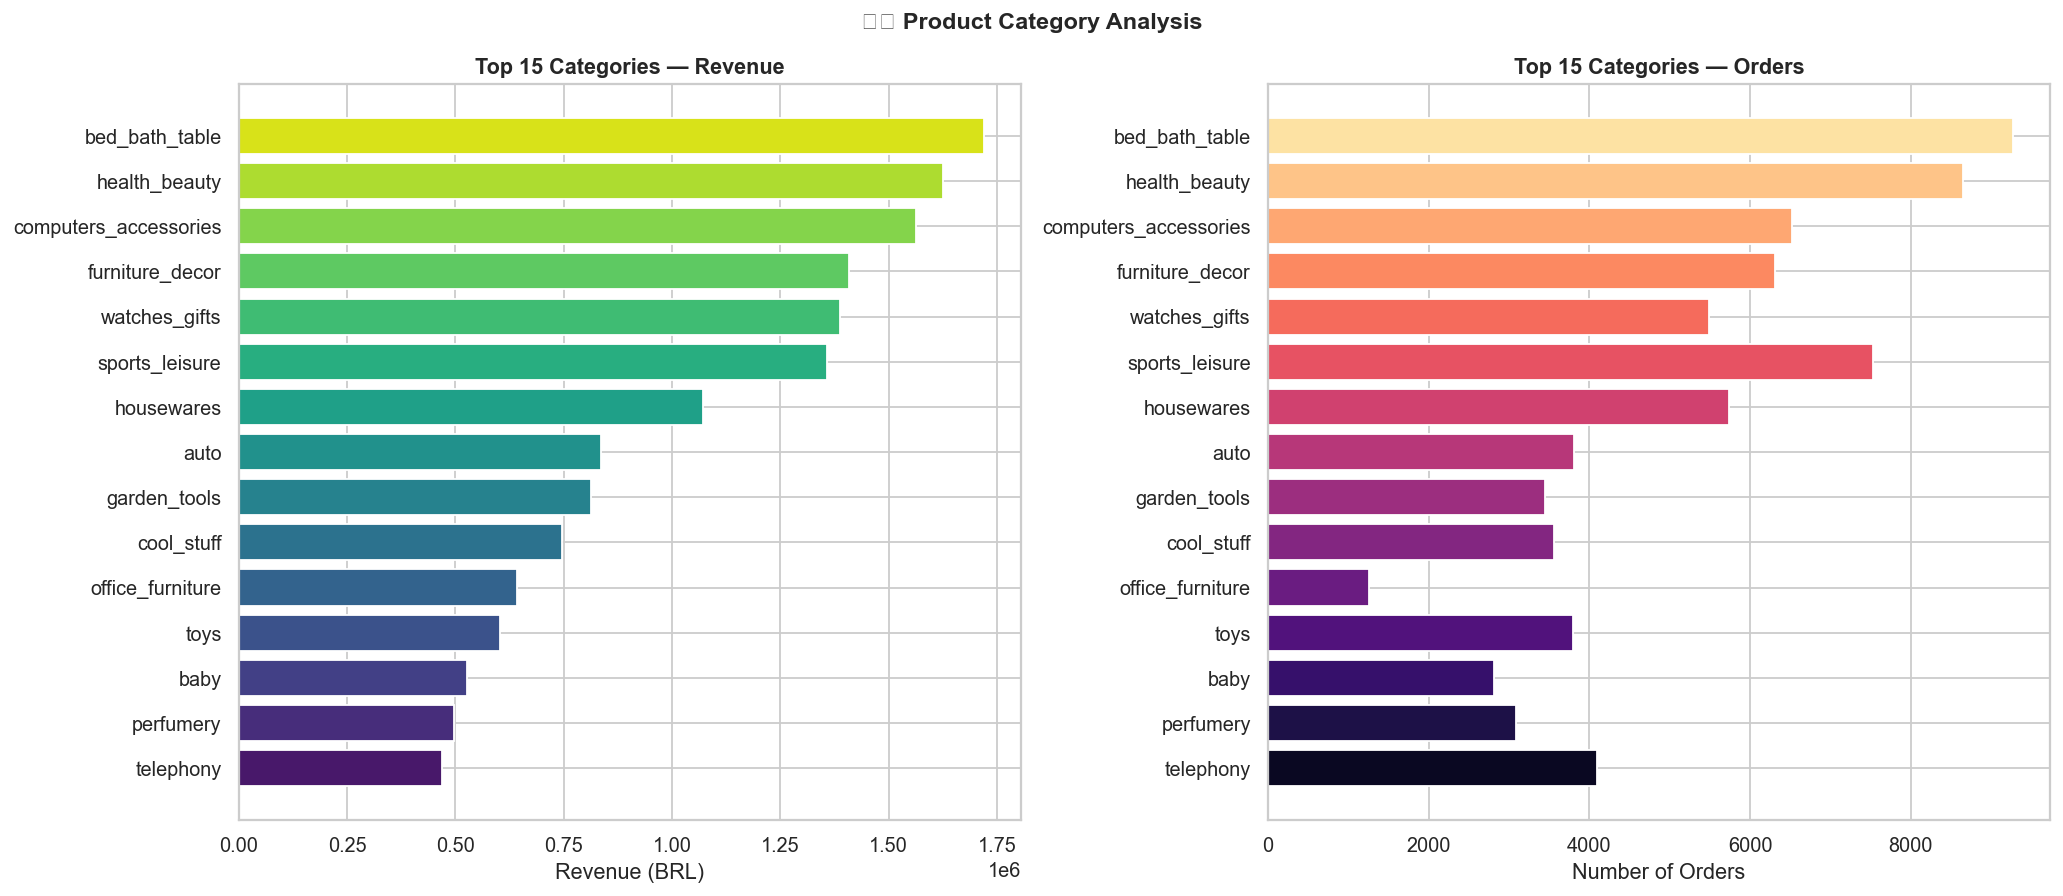

✅ Chart 3 saved!


In [11]:
cat_grp = df_clean.groupby('product_category_name_english').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index().sort_values('revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(cat_grp['product_category_name_english'][::-1],
             cat_grp['revenue'][::-1],
             color=sns.color_palette('viridis', 15))
axes[0].set_title('Top 15 Categories — Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (BRL)')

axes[1].barh(cat_grp['product_category_name_english'][::-1],
             cat_grp['orders'][::-1],
             color=sns.color_palette('magma', 15))
axes[1].set_title('Top 15 Categories — Orders', fontweight='bold')
axes[1].set_xlabel('Number of Orders')

plt.suptitle('🛍️ Product Category Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_03_categories.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

### Trạng thái đơn

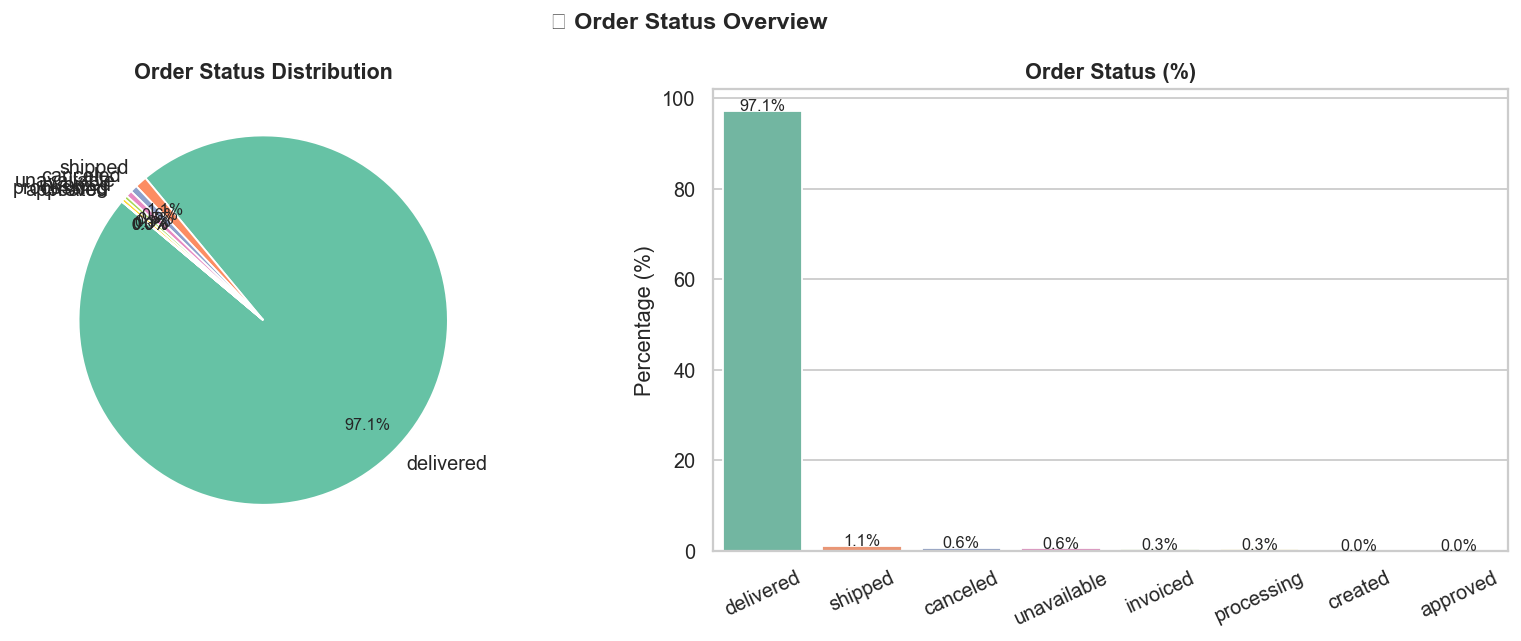

✅ Chart 4 saved!


In [13]:
status_grp = df['order_status'].value_counts().reset_index()
status_grp.columns = ['status', 'count']
status_grp['pct'] = (
    status_grp['count'] / status_grp['count'].sum() * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_pie = sns.color_palette('Set2', len(status_grp))

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    status_grp['count'],
    labels=status_grp['status'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_pie,
    pctdistance=0.8)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Order Status Distribution', fontweight='bold')

# Bar chart
sns.barplot(data=status_grp, x='status', y='pct',
            palette='Set2', ax=axes[1])
axes[1].set_title('Order Status (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=25)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2,
                      p.get_height() + 0.1),
                     ha='center', fontsize=9)

plt.suptitle('❌ Order Status Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_status.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

### Review Score và Thời gian giao hàng

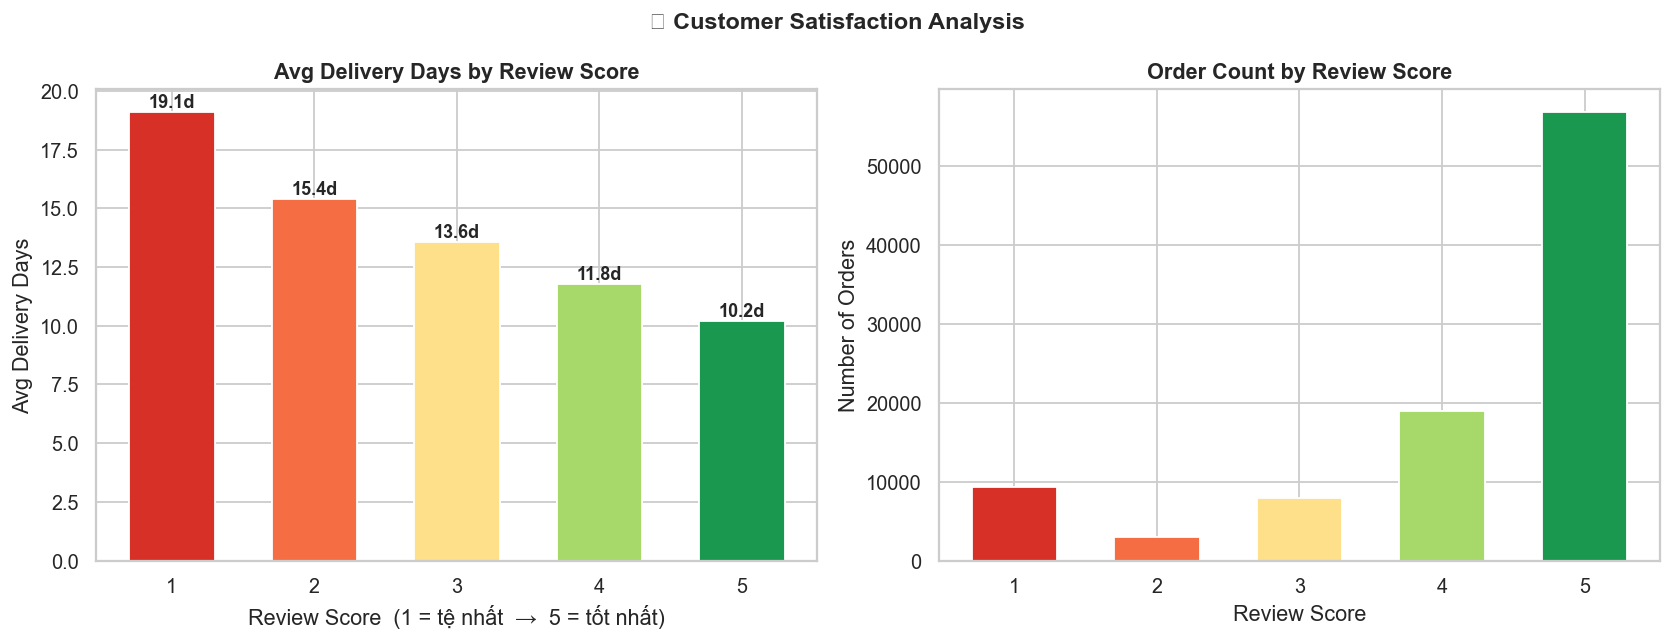

✅ Chart 5 saved!


In [14]:
rev_del = df_clean.groupby('review_score').agg(
    avg_days=('delivery_days', 'mean'),
    count=('order_id', 'nunique')
).reset_index()

score_colors = ['#d73027','#f46d43','#fee08b','#a6d96a','#1a9850']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart trái — Avg delivery days
bars = axes[0].bar(rev_del['review_score'], rev_del['avg_days'],
                   color=score_colors, width=0.6)
axes[0].set_title('Avg Delivery Days by Review Score',
                  fontweight='bold')
axes[0].set_xlabel('Review Score  (1 = tệ nhất  →  5 = tốt nhất)')
axes[0].set_ylabel('Avg Delivery Days')
for bar, row in zip(bars, rev_del.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{row.avg_days:.1f}d',
                 ha='center', fontweight='bold', fontsize=10)

# Chart phải — Số đơn theo score
axes[1].bar(rev_del['review_score'], rev_del['count'],
            color=score_colors, width=0.6)
axes[1].set_title('Order Count by Review Score', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Number of Orders')

plt.suptitle('⭐ Customer Satisfaction Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_05_reviews.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

### Phương pháp giao hàng

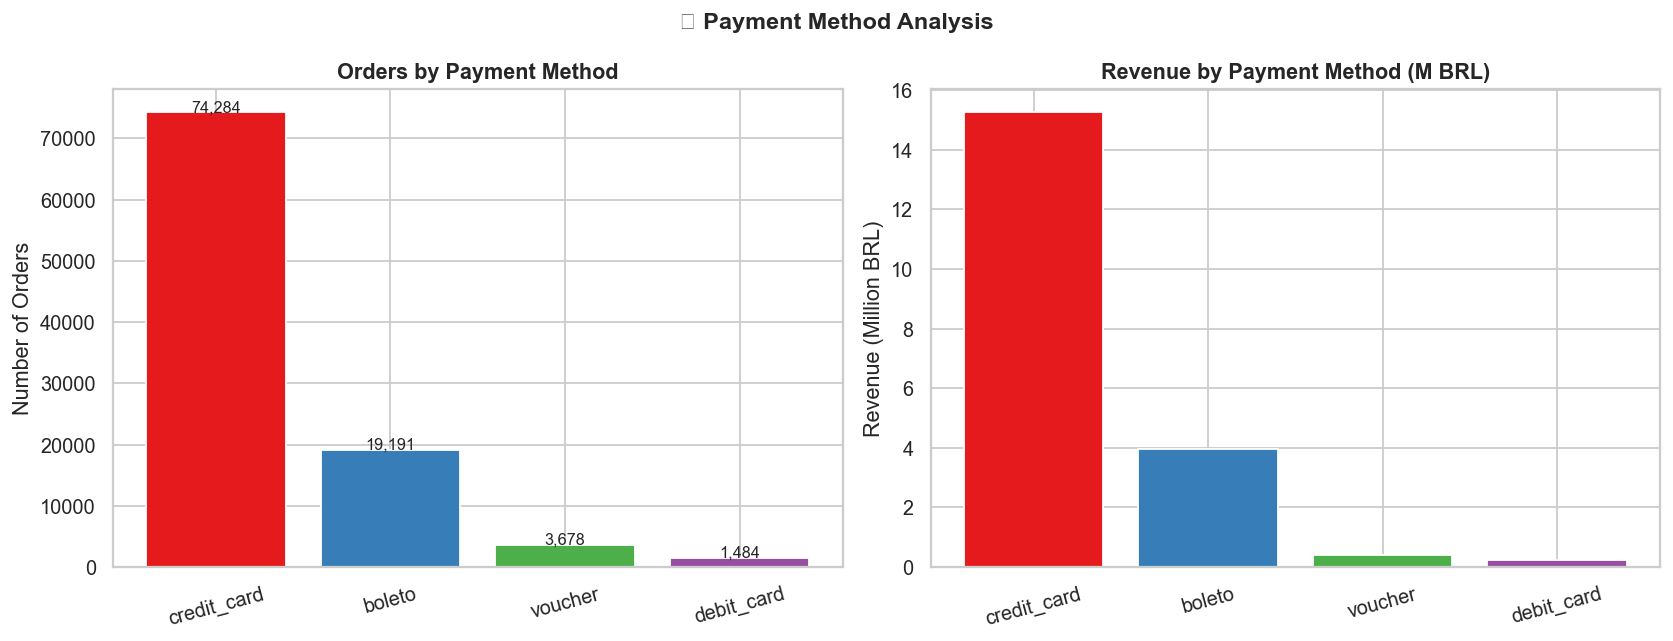

✅ Chart 6 saved!


In [16]:
pay = df_clean.groupby('payment_type').agg(
    count=('order_id', 'nunique'),
    total=('payment_value', 'sum')
).reset_index().sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pal = sns.color_palette('Set1', len(pay))

axes[0].bar(pay['payment_type'], pay['count'], color=pal)
axes[0].set_title('Orders by Payment Method', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2,
                      p.get_height() + 100),
                     ha='center', fontsize=9)

axes[1].bar(pay['payment_type'], pay['total']/1e6, color=pal)
axes[1].set_title('Revenue by Payment Method (M BRL)',
                  fontweight='bold')
axes[1].set_ylabel('Revenue (Million BRL)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('💳 Payment Method Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_06_payment.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

### Phân phối thời gian giao hàng 

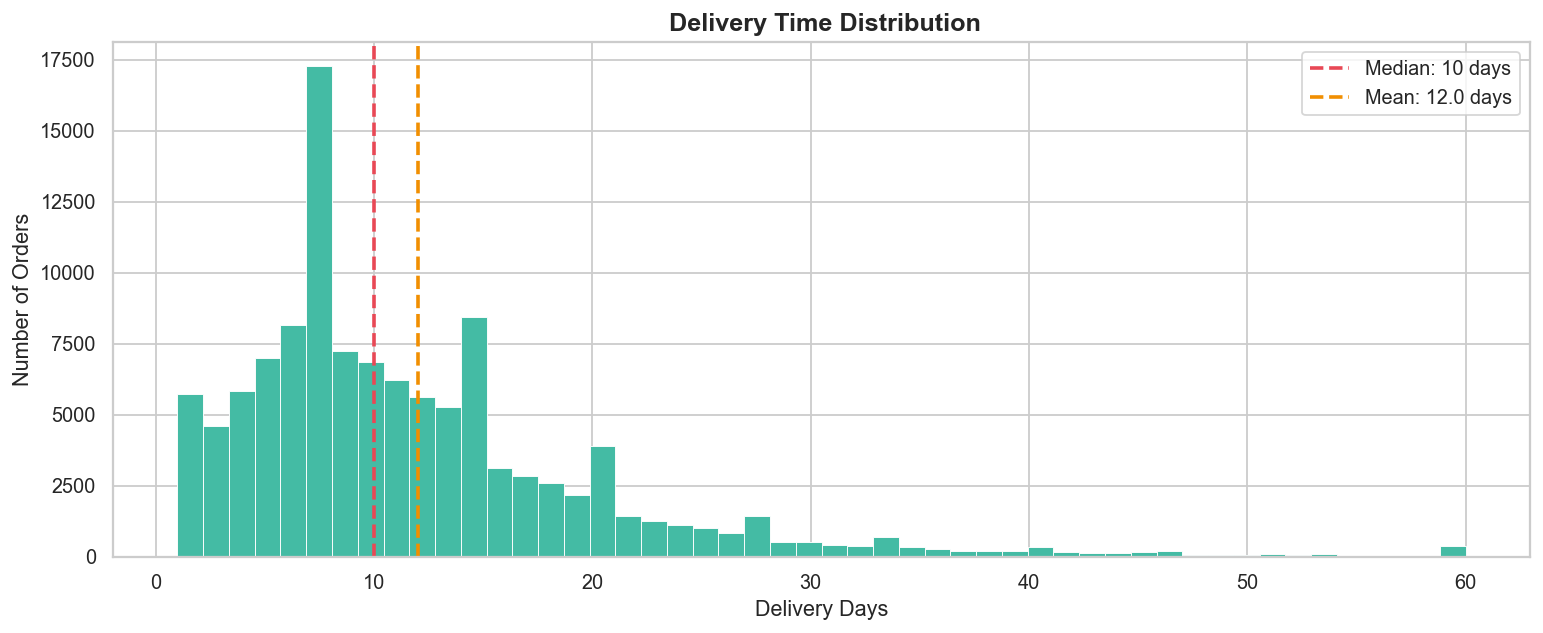

✅ Chart 7 saved!


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_clean['delivery_days'].clip(0, 60),
        bins=50, color='#44BBA4',
        edgecolor='white', linewidth=0.5)

ax.axvline(df_clean['delivery_days'].median(),
           color='#E84855', linestyle='--', linewidth=2,
           label=f"Median: {df_clean['delivery_days'].median():.0f} days")
ax.axvline(df_clean['delivery_days'].mean(),
           color='#F18F01', linestyle='--', linewidth=2,
           label=f"Mean: {df_clean['delivery_days'].mean():.1f} days")

ax.set_title(' Delivery Time Distribution',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Number of Orders')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('chart_07_delivery.png', dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

### Tổng kết số liệu

In [18]:
print("="*55)
print("  📊  KEY METRICS SUMMARY")
print("="*55)
print(f"  Total Revenue      : "
      f"{df_clean['payment_value'].sum():>15,.0f} BRL")
print(f"  Total Orders       : "
      f"{df_clean['order_id'].nunique():>15,}")
print(f"  Avg Order Value    : "
      f"{df_clean['payment_value'].mean():>15.2f} BRL")
print(f"  Avg Review Score   : "
      f"{df_clean['review_score'].mean():>15.2f} / 5.0")
print(f"  Avg Delivery Days  : "
      f"{df_clean['delivery_days'].mean():>15.1f} days")
cancel = (df[df['order_status']=='canceled'].shape[0]
          / df.shape[0] * 100)
print(f"  Cancellation Rate  : {cancel:>14.2f} %")
print(f"  Top State          : "
      f"{state.iloc[0]['customer_state']:>15}")
print(f"  Top Category       : "
      f"{cat_grp.iloc[0]['product_category_name_english']:>15}")
print("="*55)

  📊  KEY METRICS SUMMARY
  Total Revenue      :      19,874,548 BRL
  Total Orders       :          96,456
  Avg Order Value    :          171.79 BRL
  Avg Review Score   :            4.08 / 5.0
  Avg Delivery Days  :            12.0 days
  Cancellation Rate  :           0.63 %
  Top State          :              SP
  Top Category       :  bed_bath_table


In [19]:
import os
os.makedirs('data', exist_ok=True)

# File 1
df_clean.to_csv('data/powerbi_main.csv', index=False)
print(f"✅ powerbi_main.csv     — {len(df_clean):,} rows")

# File 2
monthly_export = df_clean.groupby('year_month').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()
monthly_export.to_csv('data/powerbi_monthly.csv', index=False)
print(f"✅ powerbi_monthly.csv  — {len(monthly_export):,} rows")

# File 3
state_export = df_clean.groupby('customer_state').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique'),
    avg_review=('review_score', 'mean'),
    avg_delivery=('delivery_days', 'mean')
).reset_index()
state_export.to_csv('data/powerbi_state.csv', index=False)
print(f"✅ powerbi_state.csv    — {len(state_export):,} rows")

# File 4
category_export = df_clean.groupby(
    'product_category_name_english'
).agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index()
category_export.to_csv('data/powerbi_category.csv', index=False)
print(f"✅ powerbi_category.csv — {len(category_export):,} rows")

print("\n🎉 Export hoàn tất!")


✅ powerbi_main.csv     — 115,689 rows
✅ powerbi_monthly.csv  — 22 rows
✅ powerbi_state.csv    — 27 rows
✅ powerbi_category.csv — 71 rows

🎉 Export hoàn tất!
